<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99221 למידה מרובת סוכנים</p>
<p>מטלה 2</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבוא:</p>
<ul>
<li>מטרת המטלה — מעבר מ-MARL טבלאי (מטלה 1) ל-MARL עמוק, באמצעות ה-codebase הרשמי של ספר הקורס</li>
<li>חלק ראשון — אימון IA2C במשימה Foraging-8x8-3p-2f-v3, וניתוח עקומות הלמידה, האנטרופיה וההפסדים מתוך results.csv</li>
<li>חלק שני — חיפוש היפר-פרמטרים על מקדם רגולריזציית האנטרופיה (entropy_coef) בשלוש ריצות נפרדות</li>
<li>חלק שלישי — השוואה בין critic עצמאי (IA2C, IPPO) ל-critic מרכזי (MAA2C, MAPPO) בסביבת המחסן הרובוטי rware-tiny-4ag, על נתוני האימון המצורפים לקורס (3 seeds, 20 מיליון צעדים)</li>
<li>חלק רביעי — הפקת וידאו rollout מ-checkpoint מאומן באמצעות eval.py</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הכנת הסביבה — שכפול ה-codebase הרשמי של הספר מ-GitHub, התקנת התלויות והתקנתו כחבילה, התקנת סביבות lb-foraging ו-rware, והתקנת xvfb ו-libglu1-mesa הנדרשים לרינדור הווידאו בסוף המחברת.</p>
</div>

In [1]:
!git clone -q --depth 1 https://github.com/marl-book/codebase.git marl-book-codebase
!pip install -q click einops "gymnasium<1.0.0" hydra-core==1.3.2 hydra-submitit-launcher imageio imageio-ffmpeg matplotlib pandas seaborn munch pyyaml torch
!pip install -q --no-deps -e marl-book-codebase
!pip install -q "git+https://github.com/uoe-agents/lb-foraging.git" "git+https://github.com/uoe-agents/robotic-warehouse.git"
!apt-get install -y -qq xvfb libglu1-mesa > /dev/null 2>&1

fatal: destination path 'marl-book-codebase' already exists and is not an empty directory.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא הספריות:</p>
<ul>
<li>ctypes.util — בדיקת זמינות ספריית GLU הנדרשת לרינדור הווידאו בסוף המחברת</li>
<li>glob — סריקת תבניות נתיבים לאיתור קובצי results.csv בתיקיות הפלט</li>
<li>os — עבודה עם נתיבים, זמני שינוי של קבצים והרצת פקודות מערכת</li>
<li>shutil — העתקת קובץ הווידאו ל-Drive בסוף המחברת</li>
<li>base64.b64encode ו-IPython.display.HTML — הטמעת וידאו ה-rollout בתוך המחברת</li>
<li>numpy — עיבוד סטטיסטי של התוצאות על פני seeds</li>
<li>pandas — טעינת קובצי results.csv כטבלאות DataFrame</li>
<li>yaml — קריאת קובצי הקונפיגורציה של hydra לזיהוי ריצות ה-multirun</li>
<li>matplotlib — ויזואליזציה; נקבע סגנון ggplot אחיד לכל המחברת</li>
<li>torch — ספריית הלמידה העמוקה שעליה בנוי ה-codebase</li>
<li>gymnasium — ממשק הסביבות שבו ממומשות lb-foraging ו-rware</li>
</ul>
<p>בנוסף, מודפסות גרסאות PyTorch ו-Gymnasium לאימות הסביבה.</p>
</div>

In [2]:
import ctypes.util
import glob
import os
import shutil
from base64 import b64encode

import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML

import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')

import torch
import gymnasium as gym

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'PyTorch   : {torch.__version__}')
print(f'Device    : {DEVICE}')
print(f'Gymnasium : {gym.__version__}')

PyTorch   : 2.11.0+cu128
Device    : cuda
Gymnasium : 0.29.1


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive — ריצות ה-codebase נכתבות תחת /content ונמחקות עם סגירת סשן ה-Colab, ולכן נדרש עיגון Drive לשמירת קובצי ה-CSV.</p>
</div>

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיב הפלט — DRIVE_PATH הוא תיקיית המטלה ב-Drive, ואליה ייכתבו בסוף המחברת שלושת קובצי ה-CSV.</p>
</div>

In [4]:
DRIVE_PATH = '/content/drive/MyDrive/MARL/HW2'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('drive path:', DRIVE_PATH)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון IA2C בסביבת level-based foraging:</p>
<ul>
<li>הסביבה — Foraging-8x8-3p-2f-v3: רשת 8x8, שלושה סוכנים ושני פריטי מזון; פריט ברמה גבוהה נאסף רק בשיתוף פעולה של סוכנים סמוכים, והתגמול מתחלק ביניהם</li>
<li>האלגוריתם — IA2C: לכל סוכן actor ו-critic עצמאיים (128x128) על תצפיתו המקומית, עדכוני n-steps של 5, קצב למידה 3e-4, 10 סביבות מקביליות</li>
<li>env.time_limit = 50 — אורך אפיזודה מרבי</li>
<li>algorithm.total_steps = 1,000,000 — תקציב האימון, כהנחיית המטלה</li>
<li>env.standardise_rewards = True — נרמול תגמולים ליציבות</li>
<li>algorithm.log_interval = 50000 — לוג לקונסול כל 50 אלף צעדים; ההערכה עצמה כל 10,000 צעדים על 100 אפיזודות, ונשמרת ל-results.csv</li>
<li>וידאו תקופתי מהאימון (algorithm.video_interval שבהנחיות) לא הופעל, כדי שלא להאריך את הריצה; ההדגמה החזותית נעשית בסעיף הווידאו בסוף המחברת באמצעות eval.py</li>
<li>seed = 0 — זרע אקראיות לשחזור</li>
<li>algorithm.model.device — ברירת המחדל של ה-codebase היא cpu; ערך המשתנה DEVICE, שנקבע בתא הייבוא לפי זמינות CUDA, משורשר לפקודה, כך שהמחברת מנצלת GPU כשקיים ורצה על CPU כשאין</li>
<li>הפקודה מורצת מתוך marlbase, כמצוין בהוראות; hydra שומר כל ריצה בתיקייה ייחודית תחת marlbase/outputs</li>
</ul>
</div>

In [5]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=ia2c env.name="lbforaging:Foraging-8x8-3p-2f-v3" env.time_limit=50 algorithm.total_steps=1000000 algorithm.name=ia2c env.standardise_rewards=True algorithm.log_interval=50000 seed=0 algorithm.model.device=' + DEVICE + '')
get_ipython().system(cmd)

(16410) [INFO] - (08/16 14:24:16) - numexpr.utils >> NumExpr defaulting to 12 threads.
A2CNetwork(
  (actor): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=1, bias=True)
        )
      )
    )
  )
  (target_critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2):

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>איתור תיקיית הריצה וטעינת התוצאות — מאתרים את קובץ results.csv העדכני שנשמר תחת outputs, טוענים אותו ל-DataFrame ומציגים את חמש נקודות ההערכה האחרונות של המדדים העיקריים.</p>
</div>

In [6]:
run_csv = sorted(glob.glob('marl-book-codebase/marlbase/outputs/lbforaging*/ia2c/*/results.csv'), key=os.path.getmtime)[-1]
df_ia2c = pd.read_csv(run_csv)

print(f'run directory     : {os.path.dirname(run_csv)}')
print(f'evaluation points : {len(df_ia2c)}')

run directory     : marl-book-codebase/marlbase/outputs/lbforaging:Foraging-8x8-3p-2f-v3/ia2c/3cee33e8
evaluation points : 99


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עקומת הלמידה — טבלה וגרף. הטבלה מציגה כל נקודת הערכה רביעית: צעד הסביבה, התשואה הממוצעת וסטיית התקן על פני 100 אפיזודות ההערכה, והאנטרופיה; אחריה שורת סיכום. הגרף מציג את אותם נתונים עם רצועת סטיית התקן.</p>
</div>

IA2C on Foraging-8x8-3p-2f-v3 (99 evaluations, every 4th shown)
  Eval     Steps    Return      Std   Entropy
     1     10000     0.239    0.215     3.470
     5     50000     0.205    0.245     3.806
     9     90000     0.153    0.233     3.225
    13    130000     0.117    0.145     4.018
    17    170000     0.400    0.490     3.748
    21    210000     0.410    0.345     3.796
    25    250000     0.338    0.356     3.645
    29    290000     0.579    0.422     3.683
    33    330000     0.747    0.286     3.486
    37    370000     0.371    0.428     3.323
    41    410000     0.929    0.214     3.270
    45    450000     0.319    0.382     3.011
    49    490000     0.717    0.374     3.075
    53    530000     0.842    0.294     3.115
    57    570000     0.810    0.351     2.754
    61    610460     0.744    0.359     2.818
    65    650950     0.930    0.212     2.561
    69    690950     0.908    0.264     2.570
    73    731010     0.868    0.314     2.503
    77    771640

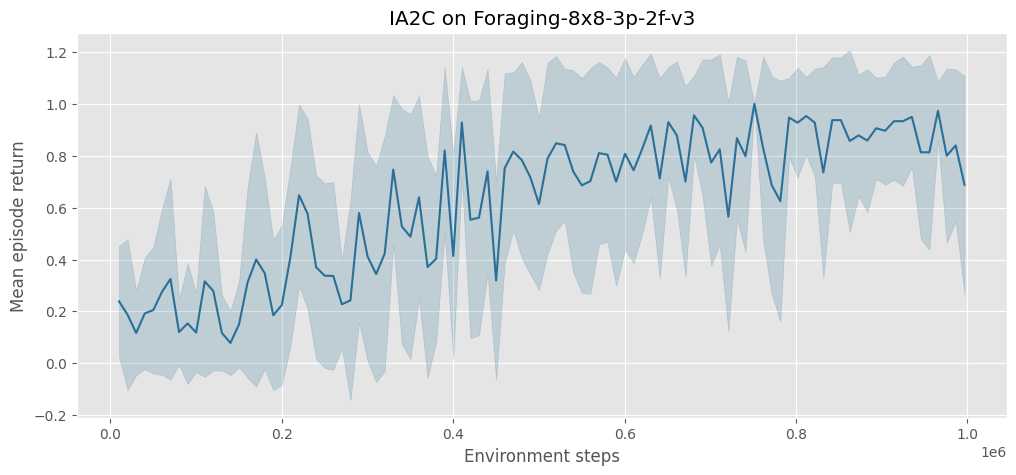

In [7]:
every = 4
print(f"IA2C on Foraging-8x8-3p-2f-v3 ({len(df_ia2c)} evaluations, every {every}th shown)")
print(f"{'Eval':>6}{'Steps':>10}{'Return':>10}{'Std':>9}{'Entropy':>10}")
for e in range(0, len(df_ia2c), every):
    r = df_ia2c.iloc[e]
    print(f"{e + 1:>6}{int(r['environment_steps']):>10}{r['mean_episode_returns']:>10.3f}"
          f"{r['std_episode_returns']:>9.3f}{r['entropy']:>10.3f}")
ret = df_ia2c['mean_episode_returns']
print()
print(f"first {ret.iloc[0]:.3f} | last {ret.iloc[-1]:.3f} | min {ret.min():.3f}"
      f" | max {ret.max():.3f} (step {int(df_ia2c['environment_steps'][ret.idxmax()])})")

fig, ax = plt.subplots(figsize=(12, 5))
steps = df_ia2c['environment_steps']
mean = df_ia2c['mean_episode_returns']
std = df_ia2c['std_episode_returns']
ax.plot(steps, mean, color='#2a6f97')
ax.fill_between(steps, mean - std, mean + std, alpha=0.2, color='#2a6f97')
ax.set_xlabel('Environment steps')
ax.set_ylabel('Mean episode return')
ax.set_title('IA2C on Foraging-8x8-3p-2f-v3')
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח עקומת הלמידה:</p>
<ul>
<li>המחצית הראשונה רועשת: מ-0.239 אחרי 10 אלף צעדים, תנודות בטווח 0.12 עד 0.21 (מינימום 0.078) והתאוששות אל 0.58 בצעד 290 אלף; במחצית השנייה המדיניות מתייצבת — 0.84 בצעד 530 אלף, נגיעה בתקרת הסביבה (1.0, כל המזון נאסף בכל אפיזודות ההערכה) בצעד 751 אלף, ואחריה רוב נקודות ההערכה מעל 0.90</li>
<li>הערך הסופי, 0.688, נמוך מהמגמה — נקודת הערכה בודדת על 100 אפיזודות רועשת דיה כדי ליפול מתחתיה, ולכן המסקנה נשענת על צורת העקומה ולא על הערך האחרון</li>
<li>רצועת סטיית התקן רחבה (0.15 עד 0.49) — הצלחת אפיזודה תלויה בתיאום בין הסוכנים — ומצטמצמת בקטעים שבהם התשואה גבוהה (0.15 בצעד 811 אלף), סימן שהמדיניות המתואמת נעשית עקבית ולא רק ברת-מזל</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מדדים נוספים מהאימון — אנטרופיית המדיניות (מדד לרמת האקראיות בבחירת הפעולות; דעיכה שלה מעידה על התגבשות מדיניות), הפסד ה-actor והפסד ה-critic לאורך הצעדים.</p>
</div>

Additional metrics (every 4th evaluation)
  Eval     Steps   Entropy   Actor L  Critic L
     1     10000     3.470     0.498    22.449
     5     50000     3.806     0.302    22.682
     9     90000     3.225    -0.292     8.195
    13    130000     4.018    -0.717     2.734
    17    170000     3.748     0.627    26.879
    21    210000     3.796     0.871    18.717
    25    250000     3.645     0.048    14.910
    29    290000     3.683     0.860    29.571
    33    330000     3.486     1.712    39.625
    37    370000     3.323    -0.075    10.556
    41    410000     3.270     2.777    41.722
    45    450000     3.011    -0.853     8.571
    49    490000     3.075     0.391    24.142
    53    530000     3.115     0.314    22.466
    57    570000     2.754    -0.361    19.254
    61    610460     2.818    -0.081    14.130
    65    650950     2.561     1.375    19.318
    69    690950     2.570    -0.367    20.003
    73    731010     2.503     0.292    24.356
    77    771640  

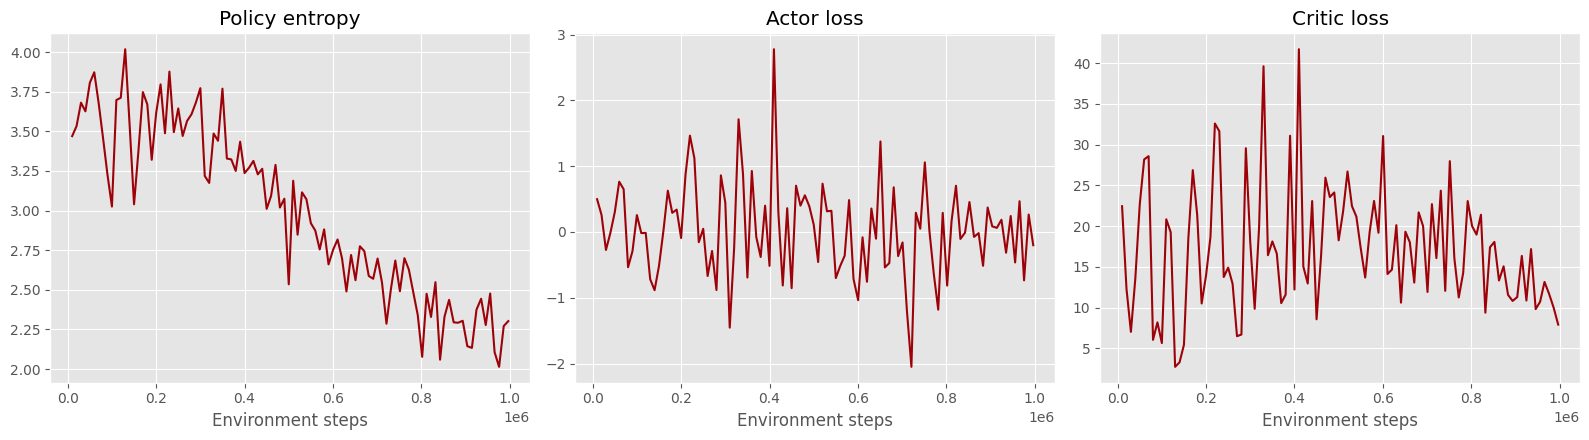

In [8]:
every = 4
print(f"Additional metrics (every {every}th evaluation)")
print(f"{'Eval':>6}{'Steps':>10}{'Entropy':>10}{'Actor L':>10}{'Critic L':>10}")
for e in range(0, len(df_ia2c), every):
    r = df_ia2c.iloc[e]
    print(f"{e + 1:>6}{int(r['environment_steps']):>10}{r['entropy']:>10.3f}"
          f"{r['actor_loss']:>10.3f}{r['value_loss']:>10.3f}")

metrics = [('entropy', 'Policy entropy'), ('actor_loss', 'Actor loss'), ('value_loss', 'Critic loss')]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, title) in zip(axes, metrics):
    ax.plot(df_ia2c['environment_steps'], df_ia2c[col], color='#9d0208')
    ax.set_xlabel('Environment steps')
    ax.set_title(title)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח המדדים:</p>
<ul>
<li>האנטרופיה גבוהה במחצית הראשונה (3.2 עד 4.0, מתוך מקסימום תאורטי של כ-5.4 לשלושה סוכנים עם שש פעולות) ודועכת אל 2.01 בסוף — הדעיכה מתואמת עם התייצבות התשואה במחצית השנייה</li>
<li>הפסד ה-actor מתנדנד סביב 0 (מ-0.85- ועד 2.78) — סימן ה-advantage מתחלף בין עדכונים, כמצופה ב-A2C</li>
<li>הפסד ה-critic רועש (2.7 עד 41.7) ללא דעיכה — ה-critic רודף אחרי יעדים נעים, ביטוי לאי-הסטציונריות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיפוש היפר-פרמטרים — מקדם רגולריזציית האנטרופיה:</p>
<ul>
<li>entropy_coef קובע את משקל בונוס האנטרופיה בהפסד ה-actor: ערך גבוה מעודד חקירה ומונע התכנסות מוקדמת, אך מקדם גבוה מדי מונע מהמדיניות להתגבש בכלל</li>
<li>נשווה שלושה ערכים: 0.001 (ברירת המחדל), 0.01 ו-0.1, כל אחד באימון של 1,000,000 צעדים עם אותו seed</li>
<li>שלוש התצורות מורצות בזו אחר זו כריצות רגילות, ללא הדגל -m: במצב multirun ה-launcher של hydra (submitit_local) מריץ את העבודה ברקע וכותב את הפלט לקובצי לוג במקום לקונסול, ולריצה של תצורה יחידה אין בכך צורך; כל ריצה מופנית באמצעות hydra.run.dir לתיקייה משלה תחת marlbase/multirun/manual, ושלושתן נטענות יחד בהמשך</li>
</ul>
</div>

In [9]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=ia2c env.name="lbforaging:Foraging-8x8-3p-2f-v3" env.time_limit=50 algorithm.total_steps=1000000 env.standardise_rewards=True algorithm.log_interval=50000 seed=0 algorithm.entropy_coef=0.001 algorithm.model.device=' + DEVICE + ' hydra.run.dir=\'multirun/manual/entropy_${algorithm.entropy_coef}\'')
get_ipython().system(cmd)

(18674) [INFO] - (08/16 14:32:44) - numexpr.utils >> NumExpr defaulting to 12 threads.
A2CNetwork(
  (actor): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=1, bias=True)
        )
      )
    )
  )
  (target_critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2):

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הריצה השנייה — entropy_coef = 0.01, פי 10 מברירת המחדל.</p>
</div>

In [10]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=ia2c env.name="lbforaging:Foraging-8x8-3p-2f-v3" env.time_limit=50 algorithm.total_steps=1000000 env.standardise_rewards=True algorithm.log_interval=50000 seed=0 algorithm.entropy_coef=0.01 algorithm.model.device=' + DEVICE + ' hydra.run.dir=\'multirun/manual/entropy_${algorithm.entropy_coef}\'')
get_ipython().system(cmd)

(20951) [INFO] - (08/16 14:41:14) - numexpr.utils >> NumExpr defaulting to 12 threads.
A2CNetwork(
  (actor): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=1, bias=True)
        )
      )
    )
  )
  (target_critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2):

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הריצה השלישית — entropy_coef = 0.1, פי 100 מברירת המחדל.</p>
</div>

In [11]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=ia2c env.name="lbforaging:Foraging-8x8-3p-2f-v3" env.time_limit=50 algorithm.total_steps=1000000 env.standardise_rewards=True algorithm.log_interval=50000 seed=0 algorithm.entropy_coef=0.1 algorithm.model.device=' + DEVICE + ' hydra.run.dir=\'multirun/manual/entropy_${algorithm.entropy_coef}\'')
get_ipython().system(cmd)

(23115) [INFO] - (08/16 14:49:28) - numexpr.utils >> NumExpr defaulting to 12 threads.
A2CNetwork(
  (actor): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2): 3 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=1, bias=True)
        )
      )
    )
  )
  (target_critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-2):

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה load_multirun — סורקת רקורסיבית את תיקיות ה-multirun, טוענת לכל ריצה את results.csv ואת config.yaml שנשמר על ידי hydra כדי לזהות את ערך entropy_coef שלה, ומחזירה את הריצות ממוינות לפי המקדם.</p>
</div>

In [12]:
def load_multirun(root='marl-book-codebase/marlbase/multirun'):
    runs = []
    for csv_path in sorted(glob.glob(f'{root}/**/results.csv', recursive=True)):
        run_dir = os.path.dirname(csv_path)
        with open(os.path.join(run_dir, '.hydra', 'config.yaml')) as f:
            config = yaml.safe_load(f)
        df = pd.read_csv(csv_path)
        resets = df.index[df['environment_steps'].diff() < 0]
        if len(resets):
            df = df.loc[resets[-1]:].reset_index(drop=True)
        runs.append((config['algorithm']['entropy_coef'], df))
    assert runs, f'no results.csv found under {root} - did the three sweep runs complete?'
    return sorted(runs, key=lambda run: run[0])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השוואת שלוש התצורות — טבלה של עקומות התשואה של שלושת ערכי entropy_coef זו מול זו, שורת סיכום לכל תצורה, ולאחריהן הגרף המשווה.</p>
</div>

IA2C entropy_coef search (99 evaluations, every 4th shown)
  Eval     Steps   coef=0.001    coef=0.01     coef=0.1
     1     10000        0.239        0.289        0.207
     5     50000        0.205        0.245        0.255
     9     90000        0.153        0.245        0.362
    13    130000        0.117        0.178        0.277
    17    170000        0.400        0.243        0.117
    21    210000        0.410        0.355        0.320
    25    250000        0.338        0.337        0.449
    29    290000        0.579        0.383        0.443
    33    330000        0.747        0.465        0.558
    37    370000        0.371        0.203        0.248
    41    410000        0.929        0.838        0.489
    45    450000        0.319        0.833        0.430
    49    490000        0.717        0.591        0.778
    53    530000        0.842        0.683        0.690
    57    570000        0.810        0.412        0.368
    61    610460        0.744        0.712   

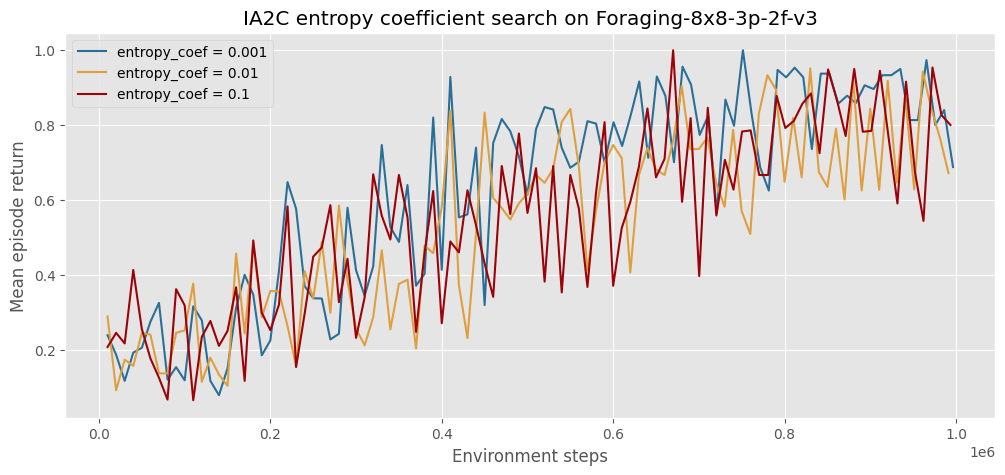

In [13]:
runs = load_multirun()

every = 4
n_evals = len(runs[0][1])
coefs = [coef for coef, _ in runs]
print(f"IA2C entropy_coef search ({n_evals} evaluations, every {every}th shown)")
print(f"{'Eval':>6}{'Steps':>10}" + "".join(f"{f'coef={c}':>13}" for c in coefs))
for e in range(0, n_evals, every):
    row = f"{e + 1:>6}{int(runs[0][1]['environment_steps'].iloc[e]):>10}"
    for _, df in runs:
        row += f"{df['mean_episode_returns'].iloc[e]:>13.3f}"
    print(row)
print()
for coef, df in runs:
    ret = df['mean_episode_returns']
    ent = df['entropy'].iloc[-1]
    print(f"coef={coef:<6} final {ret.iloc[-1]:.3f} | peak {ret.max():.3f}"
          f" (step {int(df['environment_steps'][ret.idxmax()])}) | final entropy {ent:.2f}")

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2a6f97', '#e09f3e', '#9d0208']
for (coef, df), color in zip(runs, colors):
    ax.plot(df['environment_steps'], df['mean_episode_returns'],
            label=f'entropy_coef = {coef}', color=color)
ax.set_xlabel('Environment steps')
ax.set_ylabel('Mean episode return')
ax.set_title('IA2C entropy coefficient search on Foraging-8x8-3p-2f-v3')
ax.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח חיפוש ההיפר-פרמטרים:</p>
<ul>
<li>ברירת המחדל entropy_coef = 0.001 משחזרת את הריצה הראשית — אותו seed, אותם ערכים (סיום 0.688, שיא 1.000 בצעד 751 אלף)</li>
<li>בתקציב מיליון צעדים שלוש התצורות לומדות היטב: 0.001 ו-0.1 נוגעות בתקרת הסביבה (1.000) ו-0.01 מגיעה ל-0.951; הערכים הסופיים — 0.688, 0.672 ו-0.800 — נמוכים מהשיאים בכל השלוש, כלומר תנודת סוף-ריצה ולא הידרדרות</li>
<li>האנטרופיות הסופיות אינן מסודרות לפי עוצמת הרגולריזציה: 0.1 אמנם משאיר את המדיניות האקראית ביותר (3.11), אך 0.01 מסיים נמוך מ-0.001 (2.16 מול 2.30) — היפוך שאין לו הסבר בהיפר-פרמטר עצמו</li>
<li>המסקנה: אין מנצח מובהק על seed יחיד — הדירוג מתהפך בין קריטריונים (לפי סיום 0.1 מוביל, לפי שיא 0.001 ו-0.1 שווים), ואף סדר האנטרופיות, שאמור לנבוע ישירות מההיפר-פרמטר, נשבר; להשוואה מוצקה יש למצע על פני כמה seeds, כפי שנעשה בנתוני rware בסעיף הבא</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השוואה בין critic עצמאי ל-critic מרכזי בסביבת rware:</p>
<ul>
<li>הסביבה — rware-tiny-4ag: מחסן רובוטי שבו ארבעה סוכנים מובילים מדפים לתחנות משלוח; התגמול דליל מאוד (רק משלוח מוצלח מזכה בנקודה), ולכן המשימה קשה מ-level-based foraging</li>
<li>ההשוואה — IA2C ו-IPPO מאמנים critic עצמאי לכל סוכן על תצפיתו המקומית; MAA2C ו-MAPPO מאמנים critic מרכזי המותנה בתצפיות המשותפות</li>
<li>ה-critic המרכזי משמש בזמן האימון בלבד (הפרדיגמה CTDE — אימון מרכזי, ביצוע מבוזר): המדיניות נותרת תלויה בתצפית המקומית, ולכן הביצוע מבוזר לחלוטין</li>
<li>אימון מלא דורש 4 אלגוריתמים על 3 seeds ו-20 מיליון צעדים כל אחד — לא ריאלי במסגרת המטלה, ולכן נעשה שימוש בנתוני האימון המצורפים לקורס, המובאים בתא הבא</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הבאת הנתונים המוכנים — שכפול sparse של ריפו התרגילים המושך את תיקיית rware_tiny_4ag בלבד, ומחיקת קובצי הווידאו וה-checkpoints שאינם נחוצים לניתוח (נדרשים רק ל-eval.py לצורך הפקת סרטונים, שאינה חלק מהניתוח כאן).</p>
</div>

In [14]:
if not os.path.isdir('deep_marl_data/rware_tiny_4ag'):
    os.system('git clone -q --depth 1 --filter=blob:none --sparse https://github.com/marl-book/marl-book-exercises.git _ex')
    os.system('cd _ex && git sparse-checkout set deep_marl_data/rware_tiny_4ag')
    os.system('mkdir -p deep_marl_data && cp -r _ex/deep_marl_data/rware_tiny_4ag deep_marl_data/ && rm -rf _ex')
    os.system('find deep_marl_data \\( -name "*.mp4" -o -name "*.pt" \\) -delete')

print(sorted(os.listdir('deep_marl_data/rware_tiny_4ag')))

['ia2c', 'ippo', 'maa2c', 'mappo']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שלמות הנתונים — לכל אחד מארבעת האלגוריתמים נספרים קובצי ה-results.csv (אחד לכל seed) ומספר נקודות ההערכה בכל קובץ, לאימות שהמבנה תואם את המצופה: 3 seeds ו-40 נקודות לכל ריצה.</p>
</div>

In [15]:
DATA_PATH = 'deep_marl_data/rware_tiny_4ag'
ALGORITHMS = ['ia2c', 'maa2c', 'ippo', 'mappo']

for algo in ALGORITHMS:
    csv_paths = sorted(glob.glob(f'{DATA_PATH}/{algo}/*/results.csv'))
    rows = len(pd.read_csv(csv_paths[0]))
    print(f'{algo:6} : {len(csv_paths)} seeds, {rows} evaluation points each')

ia2c   : 3 seeds, 40 evaluation points each
maa2c  : 3 seeds, 40 evaluation points each
ippo   : 3 seeds, 40 evaluation points each
mappo  : 3 seeds, 40 evaluation points each


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה load_algorithm_runs — טוענת עבור אלגוריתם נתון את קובצי results.csv של שלושת ה-seeds, ומחזירה את גריד צעדי הסביבה המשותף ומטריצה בגודל (seeds, נקודות הערכה) של מדד נבחר.</p>
</div>

In [16]:
def load_algorithm_runs(data_path, algo, metric='mean_episode_returns'):
    dfs = [pd.read_csv(path) for path in sorted(glob.glob(f'{data_path}/{algo}/*/results.csv'))]
    steps = dfs[0]['environment_steps'].values
    values = np.stack([df[metric].values for df in dfs])
    return steps, values

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ההשוואה המרכזית — טבלת התשואה הממוצעת (על פני שלושת ה-seeds) של כל אלגוריתם בכל נקודת הערכה רביעית, טבלת סיכום עם הפירוט לכל seed, ולאחריהן גרף העקומות עם רצועת סטיית התקן בין ה-seeds.</p>
</div>

rware-tiny-4ag: mean return over 3 seeds (every 4th evaluation)
  Eval       Steps     IA2C    MAA2C     IPPO    MAPPO
     1      500000     0.17     0.27     0.00     0.10
     5     2500000     0.03     0.07     0.03     0.13
     9     4500000     0.30     0.17     0.43     0.37
    13     6500000     1.43     0.47     1.10     1.23
    17     8500000     3.30     0.70     1.67     1.67
    21    10500000     2.60     1.00     2.20     2.00
    25    12500000     3.90     1.53     3.63     3.90
    29    14500000     5.90     2.40     8.20     4.43
    33    16500000     9.17     2.80     9.33     6.20
    37    18500000    11.27     2.77     8.00     8.63

          final mean  std/seeds   per-seed final returns
    IA2C       16.33      11.61    23.1    0.0   25.9
   MAA2C        3.63       0.68     2.7    3.9    4.3
    IPPO        9.83       6.17     9.4   17.6    2.5
   MAPPO       11.00       4.26    16.0    5.6   11.4


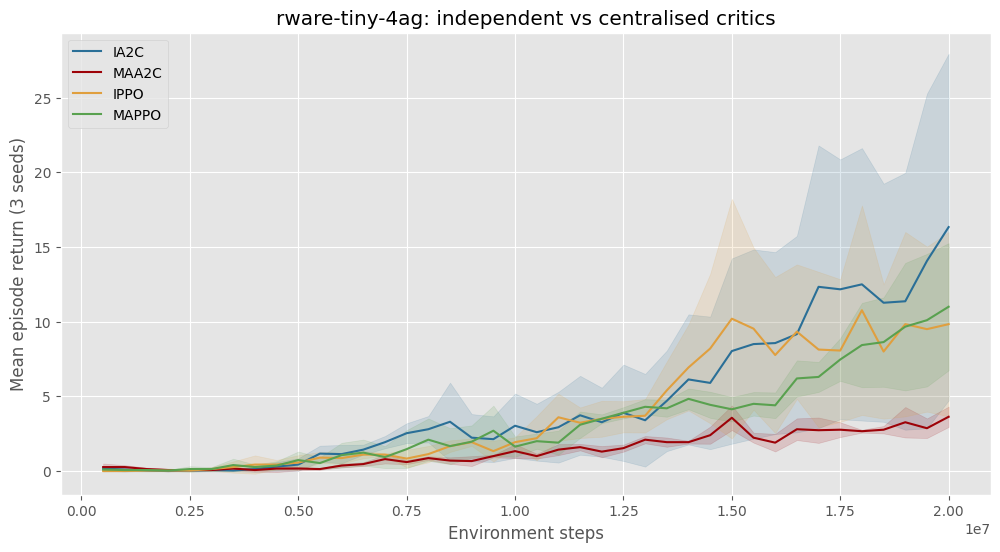

In [17]:
every = 4
data = {algo: load_algorithm_runs(DATA_PATH, algo) for algo in ALGORITHMS}
steps = data['ia2c'][0]
n_evals = len(steps)
print(f"rware-tiny-4ag: mean return over 3 seeds (every {every}th evaluation)")
print(f"{'Eval':>6}{'Steps':>12}" + "".join(f"{a.upper():>9}" for a in ALGORITHMS))
for e in range(0, n_evals, every):
    row = f"{e + 1:>6}{int(steps[e]):>12}"
    for algo in ALGORITHMS:
        row += f"{data[algo][1][:, e].mean():>9.2f}"
    print(row)
print()
print(f"{'':>8}{'final mean':>12}{'std/seeds':>11}   per-seed final returns")
for algo in ALGORITHMS:
    returns = data[algo][1]
    per_seed = "  ".join(f"{v:5.1f}" for v in returns[:, -1])
    print(f"{algo.upper():>8}{returns[:, -1].mean():>12.2f}{returns[:, -1].std():>11.2f}   {per_seed}")

COLORS = {'ia2c': '#2a6f97', 'maa2c': '#9d0208', 'ippo': '#e09f3e', 'mappo': '#59a14f'}

fig, ax = plt.subplots(figsize=(12, 6))
for algo in ALGORITHMS:
    steps, returns = data[algo]
    mean, std = returns.mean(axis=0), returns.std(axis=0)
    ax.plot(steps, mean, label=algo.upper(), color=COLORS[algo])
    ax.fill_between(steps, mean - std, mean + std, alpha=0.15, color=COLORS[algo])
ax.set_xlabel('Environment steps')
ax.set_ylabel('Mean episode return (3 seeds)')
ax.set_title('rware-tiny-4ag: independent vs centralised critics')
ax.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ההשוואה:</p>
<ul>
<li>IA2C מגיע לתשואה הממוצעת הגבוהה ביותר (16.3) אך עם השונות הגדולה ביותר (סטיית תקן 11.6): שני seeds מגיעים ל-23 עד 26, ואחד קורס ל-0 ואינו לומד כלל</li>
<li>MAA2C היציב ביותר (3.6, סטיית תקן 0.7) וגם הנמוך — ה-critic המרכזי מייצב את הלמידה אך מאט אותה</li>
<li>בזוג ה-PPO התמונה ברורה יותר: MAPPO משיג גם ממוצע גבוה יותר (11.0 מול 9.8) וגם שונות נמוכה יותר (4.3 מול 6.2) מ-IPPO</li>
<li>המסקנה הזהירה: עם 3 seeds וכוונון מינימלי (כמצוין בחומרי הקורס), הדירוג המוחלט רועש; הממצא העקבי הוא שה-critic המרכזי מקטין את השונות בין ריצות — יתרון היציבות של CTDE — בעוד לומדים עצמאיים יכולים להגיע גבוה אך גם לקרוס כליל</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מדדים נוספים בהשוואה בין האלגוריתמים — אנטרופיית המדיניות, הפסד ה-actor והפסד ה-critic, כממוצע על פני שלושת ה-seeds של כל אלגוריתם.</p>
</div>

Final value of each metric, mean over 3 seeds
           entropy  actor_loss  value_loss
    IA2C      0.87      -0.141        19.5
   MAA2C      1.71      -0.250        44.2
    IPPO      0.74       0.026        13.1
   MAPPO      1.18      -0.485        56.0

First -> last entropy per algorithm (mean over seeds)
    IA2C  3.98 -> 0.87
   MAA2C  3.75 -> 1.71
    IPPO  2.57 -> 0.74
   MAPPO  2.29 -> 1.18


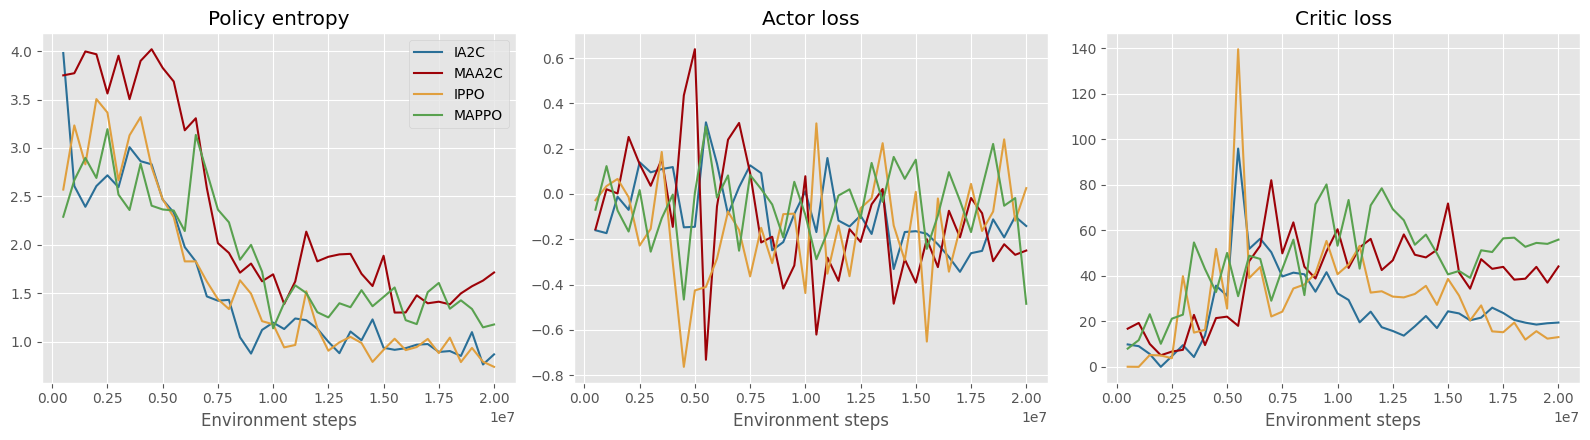

In [18]:
print("Final value of each metric, mean over 3 seeds")
print(f"{'':>8}{'entropy':>10}{'actor_loss':>12}{'value_loss':>12}")
for algo in ALGORITHMS:
    vals = []
    for metric in ['entropy', 'actor_loss', 'value_loss']:
        _, values = load_algorithm_runs(DATA_PATH, algo, metric)
        vals.append(values.mean(axis=0)[-1])
    print(f"{algo.upper():>8}{vals[0]:>10.2f}{vals[1]:>12.3f}{vals[2]:>12.1f}")
print()
print("First -> last entropy per algorithm (mean over seeds)")
for algo in ALGORITHMS:
    _, values = load_algorithm_runs(DATA_PATH, algo, 'entropy')
    m = values.mean(axis=0)
    print(f"{algo.upper():>8}  {m[0]:.2f} -> {m[-1]:.2f}")

metrics = [('entropy', 'Policy entropy'), ('actor_loss', 'Actor loss'), ('value_loss', 'Critic loss')]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (metric, title) in zip(axes, metrics):
    for algo in ALGORITHMS:
        steps, values = load_algorithm_runs(DATA_PATH, algo, metric)
        ax.plot(steps, values.mean(axis=0), label=algo.upper(), color=COLORS[algo])
    ax.set_xlabel('Environment steps')
    ax.set_title(title)
axes[0].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מדדי ה-rware:</p>
<ul>
<li>אנטרופיה: הלומדים העצמאיים מתכנסים למדיניות נחושה (IA2C ‏3.98→0.87, IPPO ‏2.57→0.74), בעוד בעלי ה-critic המרכזי נותרים אקראיים יותר בסוף האימון (MAA2C ‏1.71, MAPPO ‏1.18)</li>
<li>value_loss: גבוה משמעותית אצל המרכזיים (44.2 ו-56.0 מול 19.5 ו-13.1) — ולא בגלל תשואות גבוהות יותר (ל-MAA2C התשואה הנמוכה ביותר והפסד כפול מ-IA2C), אלא כי רגרסיה על ערך המותנה בתצפיות המשותפות של ארבעה סוכנים היא בעיה קשה יותר, ומדיניות שנותרה אקראית מוסיפה רעש ליעדים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייצוא התוצאות ל-CSV — שלושת הניסויים של המחברת נשמרים ל-Drive:</p>
<ul>
<li>hw2_lbf_ia2c.csv — הריצה הראשית, שורה לכל אחת מ-99 נקודות ההערכה עם כל המדדים שה-codebase מתעד</li>
<li>hw2_lbf_entropy_search.csv — שלוש ריצות חיפוש ההיפר-פרמטרים, עם עמודת entropy_coef לזיהוי התצורה</li>
<li>hw2_rware_comparison.csv — נתוני ה-rware המצורפים לקורס, עם עמודות algorithm ו-seed (4 אלגוריתמים × 3 seeds × 40 נקודות)</li>
</ul>
<p>הקבצים נכתבים כפי שהם מגיעים מ-results.csv של ה-codebase, ללא עיבוד, כך שהם ניתנים להשוואה ישירה מול ריצות אחרות.</p>
</div>

In [19]:
paths = {}

paths['main'] = os.path.join(DRIVE_PATH, 'hw2_lbf_ia2c.csv')
df_ia2c.to_csv(paths['main'], index=False)

sweep = pd.concat([df.assign(entropy_coef=coef) for coef, df in runs], ignore_index=True)
sweep = sweep[['entropy_coef'] + [c for c in sweep.columns if c != 'entropy_coef']]
paths['sweep'] = os.path.join(DRIVE_PATH, 'hw2_lbf_entropy_search.csv')
sweep.to_csv(paths['sweep'], index=False)

frames = []
for algo in ALGORITHMS:
    for path in sorted(glob.glob(f'{DATA_PATH}/{algo}/*/results.csv')):
        seed = os.path.basename(os.path.dirname(path))
        frames.append(pd.read_csv(path).assign(algorithm=algo, seed=seed))
rware = pd.concat(frames, ignore_index=True)
rware = rware[['algorithm', 'seed'] + [c for c in rware.columns if c not in ('algorithm', 'seed')]]
paths['rware'] = os.path.join(DRIVE_PATH, 'hw2_rware_comparison.csv')
rware.to_csv(paths['rware'], index=False)

for name, path in paths.items():
    print(f'{name:6} -> {os.path.basename(path):32} {len(pd.read_csv(path)):>4} rows')

main   -> hw2_lbf_ia2c.csv                   99 rows
sweep  -> hw2_lbf_entropy_search.csv        297 rows
rware  -> hw2_rware_comparison.csv          480 rows


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפקת וידאו מ-checkpoint — סגירת סעיף ה-eval של המטלה:</p>
<ul>
<li>המטלה מציעה לטעון checkpoint מאומן ולהפיק וידאו של rollout באמצעות eval.py; נעשה זאת על הריצה החזקה בנתונים המצורפים — IA2C על seed 2, שהגיעה ל-25.9</li>
<li>קובצי ה-checkpoint הושמטו בתא הבאת הנתונים לחיסכון בנפח, ולכן נמשך כאן ה-checkpoint הסופי בלבד (model_s20000000.pt, כ-1.3MB) באותו מנגנון sparse</li>
<li>ממשק eval.py שונה מההנחיות: הסקריפט קורא את config.yaml מתיקיית הריצה ובונה ממנו את הסביבה, ולכן אין להעביר לו env.name או env.time_limit; הנתיב נפתר יחסית ל-marlbase, ולכן מועבר נתיב מוחלט; גם הפרמטר video_frames שבהנחיות אינו נקרא בפועל — אורך הווידאו (1000 פריימים) נקבע מ-config.yaml של הריצה</li>
<li>סביבת rware מרונדרת ב-pyglet, הדורש תצוגה וספריית GLU — שניהם מותקנים בראש המחברת, וה-eval מורץ תחת xvfb-run</li>
<li>ללא load_step נטען ה-checkpoint האחרון (וכאן היחיד); הווידאו נכתב ל-marlbase/evals/&lt;id&gt;/eval.mp4, והתא הבא מטמיע אותו</li>
</ul>
</div>

In [20]:
print('xvfb:', os.system('which xvfb-run > /dev/null 2>&1') == 0,
      '| GLU:', ctypes.util.find_library('GLU') or 'MISSING')
assert ctypes.util.find_library('GLU'), 'libGLU still missing - apt install failed'

ckpt_dir = 'deep_marl_data/rware_tiny_4ag/ia2c/2/checkpoints'
if not glob.glob(f'{ckpt_dir}/model_s*.pt'):
    os.system('git clone -q --depth 1 --filter=blob:none --sparse https://github.com/marl-book/marl-book-exercises.git _ckpt')
    os.system('cd _ckpt && git sparse-checkout set deep_marl_data/rware_tiny_4ag/ia2c/2/checkpoints')
    os.system('mkdir -p ' + ckpt_dir + ' && cp _ckpt/' + ckpt_dir + '/*.pt ' + ckpt_dir + '/ && rm -rf _ckpt')
assert glob.glob(f'{ckpt_dir}/model_s*.pt'), 'checkpoint fetch failed'
print('checkpoints:', os.listdir(ckpt_dir))

run_dir = os.path.abspath('deep_marl_data/rware_tiny_4ag/ia2c/2')
cmd = ('cd marl-book-codebase/marlbase && HYDRA_FULL_ERROR=1 xvfb-run -a python eval.py path=' + run_dir + ' seed=0')
get_ipython().system(cmd)

videos = glob.glob('marl-book-codebase/marlbase/evals/*/eval.mp4')
assert videos, 'eval.py did not produce a video - check its output above'
video_path = max(videos, key=os.path.getmtime)
print(f'video: {video_path} ({os.path.getsize(video_path) / 1e6:.1f} MB)')

xvfb: True | GLU: libGLU.so.1
checkpoints: ['model_s20000000.pt']
A2CNetwork(
  (actor): MultiAgentSharedNetwork(
    (networks): ModuleList(
      (0): RNNNetwork(
        (first_layer): Linear(in_features=71, out_features=128, bias=True)
        (rnn): GRU(128, 128)
        (activation): ReLU()
        (final_layer): Linear(in_features=128, out_features=5, bias=True)
      )
    )
  )
  (critic): MultiAgentSharedNetwork(
    (networks): ModuleList(
      (0): RNNNetwork(
        (first_layer): Linear(in_features=71, out_features=128, bias=True)
        (rnn): GRU(128, 128)
        (activation): ReLU()
        (final_layer): Linear(in_features=128, out_features=1, bias=True)
      )
    )
  )
  (target_critic): MultiAgentSharedNetwork(
    (networks): ModuleList(
      (0): RNNNetwork(
        (first_layer): Linear(in_features=71, out_features=128, bias=True)
        (rnn): GRU(128, 128)
        (activation): ReLU()
        (final_layer): Linear(in_features=128, out_features=1, bias=T

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטמעת הווידאו במחברת — הקובץ נקרא, מקודד ל-base64 ומוצג כנגן וידאו מוטמע, כך שה-rollout צפוי ישירות בתוך המחברת ללא הורדה.</p>
</div>

In [21]:
video_data = b64encode(open(video_path, 'rb').read()).decode()
HTML(f'<video width="640" controls loop><source src="data:video/mp4;base64,{video_data}" type="video/mp4"></video>')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שמירת הסרטון ל-Drive — סרטון ה-rollout שהופק מה-checkpoint מועתק בשם מזהה, כך שהוא נשמר גם אחרי סגירת סשן ה-Colab.</p>
</div>

In [22]:
name = 'HW2_rware_ia2c_eval.mp4'
shutil.copyfile(video_path, os.path.join(DRIVE_PATH, name))

print(f'{name:34} {os.path.getsize(os.path.join(DRIVE_PATH, name)) / 1e6:>5.1f} MB')

HW2_rware_ia2c_eval.mp4              0.4 MB


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הווידאו:</p>
<ul>
<li>הסרטון מציג שתי אפיזודות של 500 צעדים כל אחת (1000 הפריימים הנ"ל, עם איפוס חד ביניהן) — הריצה שממנה הופק, IA2C seed 2, הגיעה לתשואה של 25.9; הסוכנים נעים בתכליתיות: איסוף מדפים מבוקשים, הובלתם לתחנות המשלוח והחזרתם</li>
<li>רגעי גודש — סוכנים חוסמים זה את זה במסדרון הצר — מופיעים לאורך הסרטון (כ-3 עד 7 אחוז מהפריימים, למשל סביב השנייה ה-24) — בעיית התיאום שמקשה על לומדים עצמאיים ב-rware יותר מב-level-based foraging, ומסבירה את השונות בין ה-seeds (אותו אלגוריתם קרס ל-0 על seed 1)</li>
<li>המדיניות הנצפית היא תוצר של 20 מיליון צעדים — פי 20 מהתקציב שהרצנו ב-level-based foraging, המחשה לפער המשאבים בין המשימות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום ומסקנות:</p>
<ul>
<li>עברנו מהאלגוריתם הטבלאי של מטלה 1 ל-MARL עמוק עם ה-codebase של הספר: אימנו IA2C ב-level-based foraging, ביצענו חיפוש היפר-פרמטרים על entropy_coef, והשווינו critics עצמאיים ומרכזיים ב-rware</li>
<li>סוכני ה-IA2C שיפרו את התשואה מ-0.239 עד לנגיעה בתקרת הסביבה (1.0) בצעד 751 אלף, והתייצבו סביב 0.9 במחצית השנייה של התקציב — מדיניות רועשת הפכה למתואמת ועקבית</li>
<li>בחיפוש ההיפר-פרמטרים לא נמצא מנצח מובהק: שתי תצורות נוגעות בתקרה (1.000) והשלישית מגיעה ל-0.951, אך הדירוג מתהפך בין קריטריונים, ואף סדר האנטרופיות הסופיות (2.30, 2.16, 3.11) אינו עוקב אחר עוצמת הרגולריזציה — השוואה על seed יחיד רועשת, ומחזקת את הצורך בריבוי seeds</li>
<li>בהשוואת ה-critics על נתוני rware: ה-critic המרכזי (CTDE) מקטין את השונות בין seeds — MAPPO עוקף את IPPO בממוצע וביציבות — בעוד לומדים עצמאיים מציגים תנודתיות קיצונית, כולל seed של IA2C שקורס ל-0</li>
<li>הפקנו וידאו rollout מ-checkpoint מאומן באמצעות eval.py — סגירת מעגל הכלים: אימון, ניתוח מדדים והדמיה</li>
<li>התמונה הכוללת ממחישה את שני צידי אי-הסטציונריות ב-MARL: היא מאפשרת ללומדים עצמאיים להגיע רחוק, אך גם מפילה אותם לחלוטין — וה-critic המרכזי הוא הכלי לריסון התופעה</li>
</ul>
</div>